In [149]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import joblib
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, f1_score, fbeta_score
from scipy.stats import randint, uniform


In [150]:
TRAIN_PATH = "./train.csv"
VALIDATION_PATH = "./validation.csv"
TEST_PATH = "./test.csv"

In [151]:
SSM_PATH = "./ssm_final_features_extended.csv"

In [152]:
tca_train_df= pd.read_csv(TRAIN_PATH)
tca_validation_df= pd.read_csv(VALIDATION_PATH)
tca_test_df= pd.read_csv(TEST_PATH)

In [153]:
j1=pd.merge(tca_train_df, tca_test_df, on=["conv_id","turn_id"], how='inner')
j2=pd.merge(tca_train_df, tca_validation_df, on=["conv_id","turn_id"], how='inner')
j3=pd.merge(tca_validation_df, tca_test_df, on=["conv_id","turn_id"], how='inner')

assert len(j1) == 0
assert len(j2) == 0
assert len(j3) == 0

In [154]:
ssm_df = pd.read_csv(SSM_PATH)

In [155]:
train_df = pd.merge(tca_train_df, ssm_df, on=["conv_id","turn_id"], how='inner')
validation_df = pd.merge(tca_validation_df, ssm_df, on=["conv_id","turn_id"], how='inner')
test_df = pd.merge(tca_test_df, ssm_df, on=["conv_id","turn_id"], how='inner')

In [156]:
train_df

,drift_acceleration,origin_drift,drift_momentum,persistent_drift_count,min_similarity,max_similarity,prev_progressive,risk_slope_3,max_toxicity_so_far,mean_risk_so_far,...,1534,1535,state_input_similarity,state_drift,state_input_distance,long_term_state_similarity,mean_squared_change_short,conv_id.1,turn_id.1,y
0,0.000000,-0.639261,0.000000,-0.5,-0.653980,-0.882655,-0.478966,-0.068303,0.221234,0.420863,...,0.006269,0.027231,0.064875,0.424472,1.060708,1.000000,0.000235,0.0,0.0,0
1,0.000000,-0.161748,0.000000,0.0,0.558162,0.110693,0.512039,6.643959,0.221234,0.039817,...,0.016303,0.008139,-0.028589,0.285567,1.122548,0.808949,0.000106,0.0,1.0,1
2,2.539898,0.178582,1.135768,0.5,0.324823,0.110693,0.142745,0.200919,0.221234,0.066037,...,-0.005324,0.010325,-0.047110,0.240984,1.142455,0.684473,0.000076,0.0,2.0,1
3,0.000000,-0.639261,0.000000,-0.5,-0.653980,-0.882655,-0.478966,-0.068303,0.278041,0.484847,...,0.018839,0.006432,-0.014866,0.387274,1.077727,1.000000,0.000195,1.0,0.0,1
4,0.000000,-0.639261,0.000000,-0.5,-0.653980,-0.882655,-0.478966,-0.068303,0.785068,1.059048,...,0.014818,-0.007148,-0.041763,0.457524,1.116935,1.000000,0.000273,4.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1947,0.000000,-0.639261,0.000000,-0.5,-0.653980,-0.882655,-0.478966,-0.068303,-0.507211,-0.429581,...,-0.025700,-0.002880,-0.000796,0.448419,1.096264,1.000000,0.000262,1102.0,0.0,0
1948,0.000000,0.428073,0.000000,0.0,0.123713,-0.212633,-0.172824,0.601409,-0.507211,-0.569675,...,0.010917,0.013514,-0.014446,0.359841,1.098020,0.671529,0.000169,1102.0,1.0,0
1949,5.109828,0.496033,1.364176,0.5,0.063709,0.134072,0.073474,0.152320,-0.507211,-0.631471,...,0.026505,0.012054,0.016844,0.232671,1.101766,0.587448,0.000070,1102.0,2.0,0
1950,0.794381,0.523732,1.224381,1.0,0.038548,0.134072,-0.214443,0.005659,-0.507211,-0.651744,...,-0.016885,0.011513,-0.023633,0.253268,1.101139,0.712542,0.000084,1102.0,3.0,0


In [157]:
assert train_df.shape[0] == tca_train_df.shape[0], "Train data merge failed"
assert validation_df.shape[0] == tca_validation_df.shape[0], "Validation data merge failed"
assert test_df.shape[0] == tca_test_df.shape[0], "Test data merge failed"

In [158]:
vector_list= list(str(col) for col in range(768+768))
train_vectors = train_df[vector_list].values
validation_vectors = validation_df[vector_list].values
test_vectors = test_df[vector_list].values

In [159]:
train_df.drop(columns=vector_list, inplace=True)
validation_df.drop(columns=vector_list, inplace=True)
test_df.drop(columns=vector_list, inplace=True)

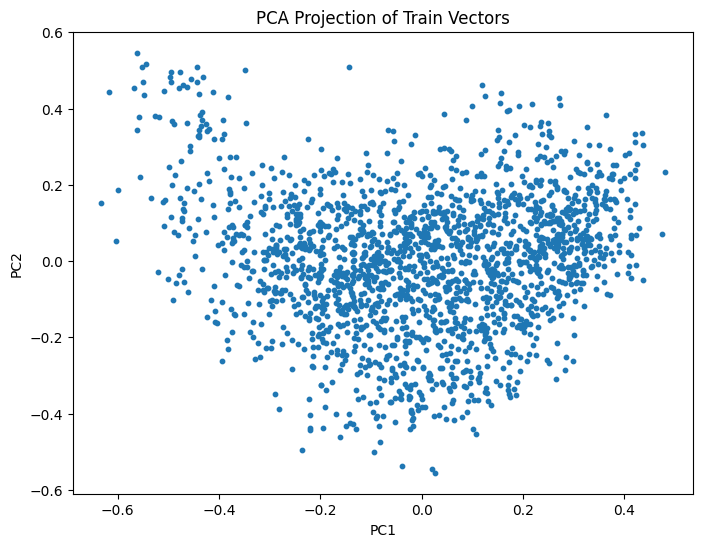

In [160]:
pca = PCA(n_components=2)   
reduced = pca.fit_transform(train_vectors)

plt.figure(figsize=(8,6))
plt.scatter(reduced[:, 0], reduced[:, 1], s=10)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Train Vectors")
plt.show()

In [161]:
pca = PCA()
pca.fit(train_vectors)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

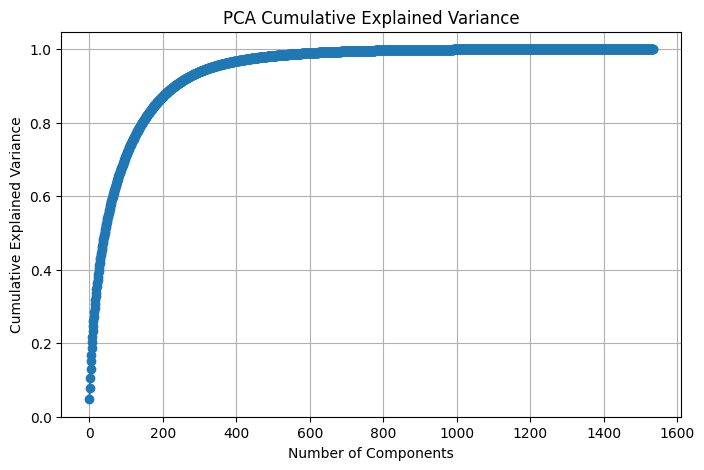

In [162]:
plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [163]:
pca = PCA(n_components=0.95)  
train_pca = pca.fit_transform(train_vectors)

print("Original dims:", train_vectors.shape[1])
print("Reduced dims:", train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original dims: 1536
Reduced dims: 331
Explained variance: 0.9502836637183141


In [164]:
train_vectors = train_pca
validation_vectors = pca.transform(validation_vectors)
test_vectors = pca.transform(test_vectors)

In [165]:
pca_columns = [f"{i}" for i in range(train_vectors.shape[1])]

train_pca_df = pd.DataFrame(train_vectors,columns=pca_columns,index=train_df.index)
validation_pca_df = pd.DataFrame(validation_vectors,columns=pca_columns,index=validation_df.index)
test_pca_df = pd.DataFrame(test_vectors,columns=pca_columns,index=test_df.index)


train_df = pd.concat([train_df, train_pca_df], axis=1)
validation_df = pd.concat([validation_df, validation_pca_df], axis=1)
test_df = pd.concat([test_df, test_pca_df], axis=1)

In [166]:
X_train = train_df.drop(columns=["label", "y"])
y_train = train_df["label"]

X_validation = validation_df.drop(columns=["label", "y"])
y_validation = validation_df["label"]

X_test = test_df.drop(columns=["label", "y"])
y_test = test_df["label"]

del train_df, validation_df, test_df

In [167]:
#keep turnid and convid for later use in error analysis and model explainability
X_train_ids = X_train[["turn_id", "conv_id"]]
X_validation_ids = X_validation[["turn_id", "conv_id"]]
X_test_ids = X_test[["turn_id", "conv_id"]]

X_train = X_train.drop(columns=["turn_id", "conv_id"])
X_validation = X_validation.drop(columns=["turn_id", "conv_id"])
X_test = X_test.drop(columns=["turn_id", "conv_id"])

In [142]:
print("Training set shape:", X_train.shape)
print("Validation set shape:", X_validation.shape)
print("Test set shape:", X_test.shape)

Training set shape: (1952, 350)
Validation set shape: (646, 350)
Test set shape: (657, 350)


In [143]:
IR=y_train[y_train==0].shape[0]/y_train[y_train==1].shape[0]
print("Imbalance Ratio:", IR)

Imbalance Ratio: 2.6282527881040894


In [144]:
def evaluate_model(y_pred, y_true):
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    return acc, report, cm

# base lines

In [41]:
X_train

,drift_acceleration,origin_drift,drift_momentum,persistent_drift_count,min_similarity,max_similarity,prev_progressive,risk_slope_3,max_toxicity_so_far,mean_risk_so_far,...,321,322,323,324,325,326,327,328,329,330
0,0.000000,-0.639261,0.000000,-0.5,-0.653980,-0.882655,-0.478966,-0.068303,0.221234,0.420863,...,-0.020715,0.015371,-0.005896,-0.008507,-0.024443,-0.001672,-0.016590,0.013589,-0.012379,-0.012714
1,0.000000,-0.161748,0.000000,0.0,0.558162,0.110693,0.512039,6.643959,0.221234,0.039817,...,-0.021364,0.015856,-0.024029,-0.020305,-0.001706,-0.014600,-0.001572,0.026071,0.001724,-0.024752
2,2.539898,0.178582,1.135768,0.5,0.324823,0.110693,0.142745,0.200919,0.221234,0.066037,...,-0.008706,0.001932,0.002008,0.006976,0.026317,-0.013938,-0.010113,0.015684,-0.005418,-0.029229
3,0.000000,-0.639261,0.000000,-0.5,-0.653980,-0.882655,-0.478966,-0.068303,0.278041,0.484847,...,-0.006633,0.009841,-0.021119,-0.003629,0.029191,-0.012312,0.003329,0.002069,0.026637,-0.015074
4,0.000000,-0.639261,0.000000,-0.5,-0.653980,-0.882655,-0.478966,-0.068303,0.785068,1.059048,...,-0.022209,-0.007134,-0.005855,0.024194,-0.002868,-0.009291,-0.011979,0.000465,-0.011842,0.007868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1947,0.000000,-0.639261,0.000000,-0.5,-0.653980,-0.882655,-0.478966,-0.068303,-0.507211,-0.429581,...,0.006197,0.041820,0.033816,-0.017313,-0.007857,-0.004772,-0.027963,-0.037374,0.006674,0.019638
1948,0.000000,0.428073,0.000000,0.0,0.123713,-0.212633,-0.172824,0.601409,-0.507211,-0.569675,...,0.001403,0.011598,-0.000988,-0.012123,0.005802,-0.022796,0.002255,-0.009434,-0.000559,0.008633
1949,5.109828,0.496033,1.364176,0.5,0.063709,0.134072,0.073474,0.152320,-0.507211,-0.631471,...,-0.019000,0.013204,-0.007365,0.004137,0.003029,-0.027621,0.009932,0.011321,-0.025761,-0.019929
1950,0.794381,0.523732,1.224381,1.0,0.038548,0.134072,-0.214443,0.005659,-0.507211,-0.651744,...,-0.017219,0.019509,0.020575,-0.009922,-0.009107,0.005925,0.019980,-0.024261,0.002445,0.006364


In [42]:
"y" in X_train.columns

False

In [43]:
params = {
    'penalty': 'l2',         
    'C': 1.0,                
    'solver': 'lbfgs',       
    'max_iter': 10000,        
    'random_state': 42
}

logreg = LogisticRegression(**params)
logreg.fit(X_train, y_train)

y_train_pred = logreg.predict(X_train)
y_validation_pred = logreg.predict(X_validation)

train_acc, train_report, train_cm = evaluate_model(y_train_pred, y_train)
val_acc, val_report, val_cm = evaluate_model(y_validation_pred, y_validation)

d:\anaconda\envs\genai-env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [44]:
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Training Classification Report:\n", train_report)
print("Validation Classification Report:\n", val_report)

Training Accuracy: 0.8442622950819673
Validation Accuracy: 0.804953560371517
Training Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89      1414
           1       0.75      0.66      0.70       538

    accuracy                           0.84      1952
   macro avg       0.81      0.79      0.80      1952
weighted avg       0.84      0.84      0.84      1952

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.88      0.87       473
           1       0.65      0.60      0.62       173

    accuracy                           0.80       646
   macro avg       0.75      0.74      0.74       646
weighted avg       0.80      0.80      0.80       646



In [45]:
params = {
    'max_depth': 5,           
    'min_samples_split': 5,    
    'min_samples_leaf': 10,     
    'max_features': None,      
    'random_state': 42
}

dtc = DecisionTreeClassifier(**params)
dtc.fit(X_train, y_train)

y_train_pred = dtc.predict(X_train)
y_validation_pred = dtc.predict(X_validation)

train_acc, train_report, train_cm = evaluate_model(y_train_pred, y_train)
val_acc, val_report, val_cm = evaluate_model(y_validation_pred, y_validation)

In [46]:
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Training Classification Report:\n", train_report)
print("Validation Classification Report:\n", val_report)

Training Accuracy: 0.8693647540983607
Validation Accuracy: 0.8637770897832817
Training Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91      1414
           1       0.77      0.75      0.76       538

    accuracy                           0.87      1952
   macro avg       0.84      0.83      0.84      1952
weighted avg       0.87      0.87      0.87      1952

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91       473
           1       0.73      0.77      0.75       173

    accuracy                           0.86       646
   macro avg       0.82      0.83      0.83       646
weighted avg       0.87      0.86      0.86       646



In [47]:
joblib.dump(dtc , "./models/decision_tree_no_parameter_tuning.joblib")

['./models/decision_tree_no_parameter_tuning.joblib']

In [48]:
params = {
    'n_estimators': 300,        
    'max_depth': 3,             
    'learning_rate': 0.01,       
    'random_state': 42,
    'n_jobs': -1,
}

xgb = XGBClassifier(**params)
xgb.fit(X_train, y_train)

# Predictions
y_train_pred = xgb.predict(X_train)
y_validation_pred = xgb.predict(X_validation)

# Evaluation
train_acc, train_report, train_cm = evaluate_model(y_train_pred, y_train)
val_acc, val_report, val_cm = evaluate_model(y_validation_pred, y_validation)

In [49]:
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Training Classification Report:\n", train_report)
print("Validation Classification Report:\n", val_report)

Training Accuracy: 0.8826844262295082
Validation Accuracy: 0.8668730650154799
Training Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92      1414
           1       0.81      0.76      0.78       538

    accuracy                           0.88      1952
   macro avg       0.86      0.84      0.85      1952
weighted avg       0.88      0.88      0.88      1952

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       473
           1       0.75      0.75      0.75       173

    accuracy                           0.87       646
   macro avg       0.83      0.83      0.83       646
weighted avg       0.87      0.87      0.87       646



In [50]:
joblib.dump(xgb , "./models/xgb_no_parameter_tuning.joblib")

['./models/xgb_no_parameter_tuning.joblib']

# hyperparameter tuning

In [51]:
base_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample" 
)

param_grid = {
    "n_estimators": [300, 400],
    "max_depth": [5, 7, 10],
    "min_samples_split": [5, 10, 15],
    "min_samples_leaf": [10, 20, 30],
    "max_features": [None, "sqrt", "log2"]
}

# -----------------------------
# Precision-leaning F-beta score
# beta < 1 → favors precision
# -----------------------------
scoring = make_scorer(fbeta_score, beta=0.8, average="macro")

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    scoring=scoring,
    n_jobs=-1,
    refit=True
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
y_train_pred = best_model.predict(X_train)
y_validation_pred = best_model.predict(X_validation)


train_acc, train_report, train_cm = evaluate_model(y_train_pred, y_train)
val_acc, val_report, val_cm = evaluate_model(y_validation_pred, y_validation)

print("Best Params:", best_params)
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("CV Best Score:", grid_search.best_score_)

Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 30, 'min_samples_split': 5, 'n_estimators': 400}
Training Accuracy: 0.8995901639344263
Validation Accuracy: 0.8188854489164087
CV Best Score: 0.6026366569907646


In [52]:
print("Training Accuracy:", train_acc)
print("Validation Accuracy:", val_acc)
print("Training Classification Report:\n", train_report)
print("Validation Classification Report:\n", val_report)

Training Accuracy: 0.8995901639344263
Validation Accuracy: 0.8188854489164087
Training Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.87      0.93      1414
           1       0.74      0.98      0.84       538

    accuracy                           0.90      1952
   macro avg       0.87      0.92      0.88      1952
weighted avg       0.92      0.90      0.90      1952

Validation Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.80      0.87       473
           1       0.61      0.88      0.72       173

    accuracy                           0.82       646
   macro avg       0.78      0.84      0.79       646
weighted avg       0.86      0.82      0.83       646



In [53]:
joblib.dump(best_model, "./models/random_forest_best.pkl")

['./models/random_forest_best.pkl']

In [ ]:
pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
scale_pos_weight = neg / pos
base_model = XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,

    # stability improvements
    tree_method="hist",
    max_delta_step=1
)

param_dist = {
    "n_estimators": randint(80, 250),
    "max_depth": randint(2, 4),
    "learning_rate": uniform(0.01, 0.05),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "reg_lambda": uniform(3.0, 10.0),
    "reg_alpha": uniform(0.0, 3.0),
    "min_child_weight": randint(5, 15)
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


scoring = make_scorer(
    fbeta_score,
    beta=0.5,
    average="binary"
)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Params: {'colsample_bytree': np.float64(0.8845021680097509), 'learning_rate': np.float64(0.059502692505213166), 'max_depth': 3, 'min_child_weight': 14, 'n_estimators': 209, 'reg_alpha': np.float64(0.9676522927158016), 'reg_lambda': np.float64(11.486697949246745), 'subsample': np.float64(0.7409863994326086)}
CV Best F-beta Score: 0.7259220810510015
Best Threshold: 0.87
Validation Best F-beta: 0.7566462167689162
Train Score: 0.882172131147541
Validation Score: 0.8390092879256966


In [92]:
y_train_proba = best_model.predict_proba(X_train)[:, 1]
y_validation_proba = best_model.predict_proba(X_validation)[:, 1]
thresholds = [i / 100 for i in range(10, 90)]
best_t = 0.5
best_score = -1

for t in thresholds:
    preds = (y_validation_proba >= t).astype(int)
    score = fbeta_score(y_validation, preds, beta=0.56)

    if score > best_score:
        best_score = score
        best_t = t

y_train_pred = (y_train_proba >= best_t).astype(int)
y_validation_pred = (y_validation_proba >= best_t).astype(int)

train_acc, train_report, train_cm = evaluate_model(y_train_pred, y_train)
validation_acc, validation_report, validation_cm = evaluate_model(y_validation_pred, y_validation)

print("Best Params:", random_search.best_params_)
print("CV Best F-beta Score:", random_search.best_score_)
print("Best Threshold:", best_t)
print("Validation Best F-beta:", best_score)
print("Train Score:", train_acc)
print("Validation Score:", validation_acc)

Best Params: {'colsample_bytree': np.float64(0.8845021680097509), 'learning_rate': np.float64(0.059502692505213166), 'max_depth': 3, 'min_child_weight': 14, 'n_estimators': 209, 'reg_alpha': np.float64(0.9676522927158016), 'reg_lambda': np.float64(11.486697949246745), 'subsample': np.float64(0.7409863994326086)}
CV Best F-beta Score: 0.7259220810510015
Best Threshold: 0.76
Validation Best F-beta: 0.7461770920906137
Train Score: 0.9641393442622951
Validation Score: 0.8606811145510835


In [93]:
print("Training Accuracy:", train_acc)
print("Training Classification Report:\n", train_report)
print("Validation Accuracy:", validation_acc)
print("Validation Classification Report:\n", validation_report)

Training Accuracy: 0.9641393442622951
Training Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.98      1414
           1       0.98      0.89      0.93       538

    accuracy                           0.96      1952
   macro avg       0.97      0.94      0.95      1952
weighted avg       0.96      0.96      0.96      1952

Validation Accuracy: 0.8606811145510835
Validation Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.91       473
           1       0.76      0.69      0.73       173

    accuracy                           0.86       646
   macro avg       0.83      0.81      0.82       646
weighted avg       0.86      0.86      0.86       646



# final test

In [169]:
model = joblib.load("./models/xgb_no_parameter_tuning.joblib")

In [170]:
y_pred=model.predict(X_test)
classification_rep = classification_report(y_test, y_pred)
print("Test Classification Report:\n", classification_rep)

Test Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.89      0.90       471
           1       0.73      0.74      0.74       186

    accuracy                           0.85       657
   macro avg       0.82      0.82      0.82       657
weighted avg       0.85      0.85      0.85       657

